<a href="https://colab.research.google.com/github/Semere-Mesfin-Gebresilassie/Semere-Mesfin-Gebresilassie/blob/main/Random_Forest(Chart_A1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
"""
ERA Chart A1 - Machine Learning for Flexible Pavement Thickness Prediction
Using Random Forest (Multi-Output Regression) with step‑function preservation.
Double surface treatment is considered a thin non‑structural layer (thickness = 0 mm).
"""

'\nERA Chart A1 - Machine Learning for Flexible Pavement Thickness Prediction\nUsing Random Forest (Multi-Output Regression) with step‑function preservation.\nDouble surface treatment is considered a thin non‑structural layer (thickness = 0 mm).\n'

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [30]:
# 1. Load and prepare the original dataset

file_path = "/content/A1 chart Final.xlsx"
df = pd.read_excel(file_path)

In [31]:
print(f"Original dataset shape: {df.shape}")
print(df.head())

Original dataset shape: (36, 7)
   Subgrade CBR (%)  Traffic ESA (millions) Base Type  Base Thickness (mm)  \
0               2.0                    0.20     GB2/3                  150   
1               2.0                    0.50     GB2/3                  150   
2               2.0                    1.10     GB2/3                  200   
3               2.0                    2.25     GB2/3                  200   
4               2.0                    4.50       GB1                  200   

   Subbase Thickness (mm)  Capping Thickness (mm)  Total Thickness (mm)  
0                     175                     250                   575  
1                     200                     275                   625  
2                     200                     300                   700  
3                     250                     300                   750  
4                     300                     300                   800  


In [32]:
# Features and targets
X = df[['Subgrade CBR (%)', 'Traffic ESA (millions)', 'Base Type']].copy()
y = df[['Base Thickness (mm)', 'Subbase Thickness (mm)', 'Capping Thickness (mm)']].copy()

In [33]:
# Encode Base Type (GB2/3 -> 0, GB1 -> 1)
le = LabelEncoder()
X['Base Type Encoded'] = le.fit_transform(X['Base Type'])  # GB2/3 becomes 0, GB1 becomes 1
X = X.drop('Base Type', axis=1)

In [34]:
# ==============================
# 2. Generate synthetic data by replicating with jitter (preserve step function)
# ==============================
def generate_synthetic_data_step(df, samples_per_cell=50, esa_jitter=0.05):
    """
    Generate synthetic data by replicating each discrete design point
    and adding small random jitter to the Traffic ESA (millions).
    Thickness values remain unchanged, preserving the step‑function nature.

    Parameters:
    - df: original DataFrame
    - samples_per_cell: number of synthetic samples per original row
    - esa_jitter: relative jitter range (e.g., 0.05 = ±5%)
    """
    synthetic_rows = []
    for _, row in df.iterrows():
        base_esa = row['Traffic ESA (millions)']
        for _ in range(samples_per_cell):
            # Add random jitter to ESA only (thickness stays constant)
            esa = base_esa * (1 + np.random.uniform(-esa_jitter, esa_jitter))
            # Ensure ESA stays positive and within reasonable bounds
            esa = max(esa, 0.01)
            synthetic_rows.append({
                'Subgrade CBR (%)': row['Subgrade CBR (%)'],
                'Traffic ESA (millions)': esa,
                'Base Type Encoded': le.transform([row['Base Type']])[0],
                'Base Thickness (mm)': row['Base Thickness (mm)'],
                'Subbase Thickness (mm)': row['Subbase Thickness (mm)'],
                'Capping Thickness (mm)': row['Capping Thickness (mm)']
            })
    synthetic_df = pd.DataFrame(synthetic_rows)
    return synthetic_df

In [35]:
# Generate synthetic data (50 replicates per original row)
synthetic_df = generate_synthetic_data_step(df, samples_per_cell=50, esa_jitter=0.05)
print(f"Synthetic dataset shape: {synthetic_df.shape}")

Synthetic dataset shape: (1800, 6)


In [36]:
# Combine original and synthetic data

# Ensure df has 'Base Type Encoded' column for concatenation
# This column was created for X and synthetic_df, but not df itself.
if 'Base Type' in df.columns and 'Base Type Encoded' not in df.columns:
    df['Base Type Encoded'] = le.transform(df['Base Type'])

combined_df = pd.concat([
    df[['Subgrade CBR (%)', 'Traffic ESA (millions)', 'Base Type Encoded',
        'Base Thickness (mm)', 'Subbase Thickness (mm)', 'Capping Thickness (mm)']],
    synthetic_df
], ignore_index=True)
print(f"Combined dataset shape: {combined_df.shape}")

Combined dataset shape: (1836, 6)


In [37]:
# Prepare features and targets for combined dataset
X_comb = combined_df[['Subgrade CBR (%)', 'Traffic ESA (millions)', 'Base Type Encoded']]
y_comb = combined_df[['Base Thickness (mm)', 'Subbase Thickness (mm)', 'Capping Thickness (mm)']]

In [38]:
# 3. Train-test split and scaling (optional for tree models)

X_train, X_test, y_train, y_test = train_test_split(
    X_comb, y_comb, test_size=0.2, random_state=42
)

# For tree-based models, scaling is not required but can be used if desired.
# We will keep unscaled for simplicity.
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 1468, Testing samples: 368


In [39]:
# 4. Train Random Forest (multi-output)

# Use MultiOutputRegressor to handle three outputs
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
multi_rf = MultiOutputRegressor(rf)

print("Training Random Forest...")
multi_rf.fit(X_train, y_train)
print("Training completed.")

Training Random Forest...
Training completed.


In [40]:
# 5. Evaluate the model

y_pred = multi_rf.predict(X_test)

# Ensure no negative predictions (clipping to zero)
y_pred = np.maximum(y_pred, 0)

output_names = ['Base Thickness (mm)', 'Subbase Thickness (mm)', 'Capping Thickness (mm)']
print("\n=== Model Evaluation on Test Set ===")
for i, name in enumerate(output_names):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"{name}: MAE = {mae:.2f} mm, RMSE = {rmse:.2f} mm, R² = {r2:.4f}")


=== Model Evaluation on Test Set ===
Base Thickness (mm): MAE = 0.07 mm, RMSE = 0.44 mm, R² = 0.9998
Subbase Thickness (mm): MAE = 0.27 mm, RMSE = 2.12 mm, R² = 0.9994
Capping Thickness (mm): MAE = 0.02 mm, RMSE = 0.27 mm, R² = 1.0000


In [41]:
# Overall R² (flattened arrays)
total_r2 = r2_score(y_test.values.flatten(), y_pred.flatten())
print(f"\nOverall R² (all thicknesses): {total_r2:.4f}")


Overall R² (all thicknesses): 0.9998


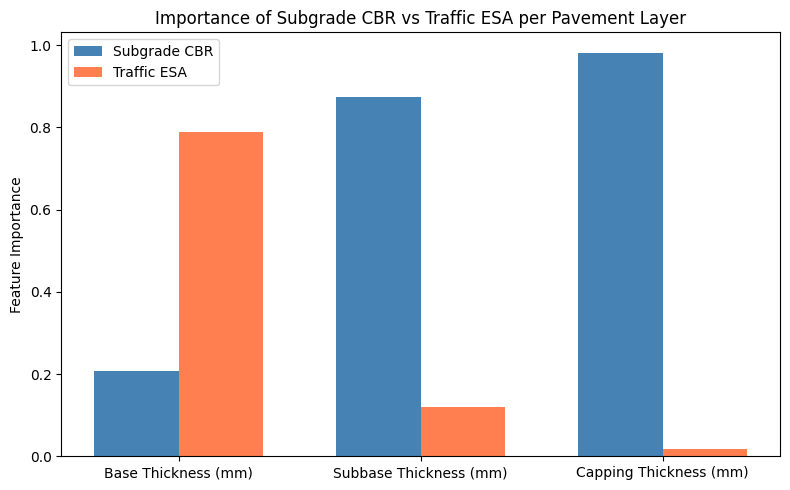

In [42]:
# 6. Feature importance (per output)

# Reconstruct the feature importance calculation for imp_df
imp_data = {
    'Subgrade CBR (%)': [],
    'Traffic ESA (millions)': []
}

# Get feature indices from X_train columns
# Assuming X_train.columns is consistent with the order of feature_importances_
subgrade_cbr_idx = X_train.columns.get_loc('Subgrade CBR (%)')
traffic_esa_idx = X_train.columns.get_loc('Traffic ESA (millions)')

for i, estimator in enumerate(multi_rf.estimators_):
    imp_data['Subgrade CBR (%)'].append(estimator.feature_importances_[subgrade_cbr_idx])
    imp_data['Traffic ESA (millions)'].append(estimator.feature_importances_[traffic_esa_idx])

imp_df = pd.DataFrame(imp_data, index=output_names)

# Define width for the bars
width = 0.35

# Plot only Traffic vs Subgrade CBR
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(output_names))
bars1 = ax.bar(x - width/2, imp_df['Subgrade CBR (%)'], width, label='Subgrade CBR', color='steelblue')
bars2 = ax.bar(x + width/2, imp_df['Traffic ESA (millions)'], width, label='Traffic ESA', color='coral')
ax.set_ylabel('Feature Importance')
ax.set_title('Importance of Subgrade CBR vs Traffic ESA per Pavement Layer')
ax.set_xticks(x)
ax.set_xticklabels(output_names)
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
# 7. Example prediction function

def predict_thickness(cbr, esa, base_type_default='GB1'):
    """
    Predict layer thicknesses using only Subgrade CBR and Traffic ESA.
    The base type is fixed to GB1 (crushed stone) by default, which is the higher-quality option.

    Parameters:
    - cbr: subgrade CBR (%)
    - esa: traffic in millions of ESALs
    - base_type_default: 'GB2/3' or 'GB1' (optional, default GB1)
    """
    # Encode base type (0 for GB2/3, 1 for GB1)
    base_enc = 0 if base_type_default == 'GB2/3' else 1
    input_data = np.array([[cbr, esa, base_enc]])
    pred = multi_rf.predict(input_data)[0]
    # Clip negative predictions to zero (safety)
    pred = np.maximum(pred, 0)

    print(f"\n=== Prediction for Subgrade CBR = {cbr}%, Traffic = {esa} million ESALs ===")
    print(f"Base Thickness (GB1 crushed stone assumed): {pred[0]:.0f} mm")
    print(f"Subbase Thickness: {pred[1]:.0f} mm")
    print(f"Capping Thickness: {pred[2]:.0f} mm")
    print(f"Total Structural Thickness: {pred.sum():.0f} mm")
    print("Note: Double surface treatment is a thin non-structural layer (thickness = 0 mm).")

# Example predictions with only CBR and ESA (using GB1 default)
predict_thickness(cbr=4.0, esa=0.8)      # CBR=4%, ESA=0.8 million
predict_thickness(cbr=15.0, esa=3.0)     # CBR=15%, ESA=3.0 million
predict_thickness(cbr=6.0, esa=1.5)      # CBR=6%, ESA=1.5 million

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



=== Prediction for Subgrade CBR = 4.0%, Traffic = 0.8 million ESALs ===
Base Thickness (GB1 crushed stone assumed): 196 mm
Subbase Thickness: 157 mm
Capping Thickness: 195 mm
Total Structural Thickness: 549 mm
Note: Double surface treatment is a thin non-structural layer (thickness = 0 mm).

=== Prediction for Subgrade CBR = 15.0%, Traffic = 3.0 million ESALs ===
Base Thickness (GB1 crushed stone assumed): 200 mm
Subbase Thickness: 250 mm
Capping Thickness: 0 mm
Total Structural Thickness: 450 mm
Note: Double surface treatment is a thin non-structural layer (thickness = 0 mm).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



=== Prediction for Subgrade CBR = 6.0%, Traffic = 1.5 million ESALs ===
Base Thickness (GB1 crushed stone assumed): 200 mm
Subbase Thickness: 154 mm
Capping Thickness: 190 mm
Total Structural Thickness: 545 mm
Note: Double surface treatment is a thin non-structural layer (thickness = 0 mm).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [44]:
# 8. Save the model and encoders for later use

joblib.dump(multi_rf, 'era_chart_A1_random_forest.pkl')
joblib.dump(le, 'label_encoder_base_type.pkl')
print("\nModel and label encoder saved successfully.")


Model and label encoder saved successfully.


In [45]:
def cost_optimization(cbr, esa, cost_per_mm_per_m2=None):
    """
    Compare GB1 and GB2/3 designs for given CBR and ESA, return the cheaper option.

    Parameters:
    - cbr: subgrade CBR (%)
    - esa: traffic in millions of ESALs
    - cost_per_mm_per_m2: dict with keys 'base', 'subbase', 'capping' (Birr/mm/m²)
      Default values are typical Ethiopian estimates (can be adjusted).
    """
    if cost_per_mm_per_m2 is None:
        cost_per_mm_per_m2 = {
            'base_gb1': 12.0,      # Crushed stone base
            'base_gb23': 8.5,      # Natural gravel base
            'subbase': 4.2,
            'capping': 2.5
        }

    results = {}
    for base_type, cost_base in [('GB1', cost_per_mm_per_m2['base_gb1']),
                                  ('GB2/3', cost_per_mm_per_m2['base_gb23'])]:
        base_enc = 0 if base_type == 'GB2/3' else 1
        input_data = np.array([[cbr, esa, base_enc]])
        pred = multi_rf.predict(input_data)[0]
        pred = np.maximum(pred, 0)   # no negative thicknesses

        base_th, subbase_th, capping_th = pred
        total_cost = (base_th * cost_base +
                      subbase_th * cost_per_mm_per_m2['subbase'] +
                      capping_th * cost_per_mm_per_m2['capping'])
        results[base_type] = {
            'thicknesses': (base_th, subbase_th, capping_th),
            'total_cost': total_cost
        }

    # Determine cheaper option
    cheaper = min(results, key=lambda x: results[x]['total_cost'])
    return results, cheaper

In [46]:

'''import tkinter as tk
from tkinter import ttk, messagebox
import numpy as np
import joblib

# Load the pre‑trained model and label encoder
multi_rf = joblib.load('era_chart_A1_random_forest.pkl')
le = joblib.load('label_encoder_base_type.pkl')

def predict_for_base_type(cbr, esa, base_type):
    """Return predicted thicknesses (base, subbase, capping) for a given base type."""
    base_enc = 0 if base_type == 'GB2/3' else 1
    inp = np.array([[cbr, esa, base_enc]])
    pred = multi_rf.predict(inp)[0]
    return np.maximum(pred, 0)

def compute_cost(base_th, subbase_th, capping_th, base_type):
    """Compute total cost using unit costs (Birr/mm/m²)."""
    unit_costs = {
        'GB1': 12.0,
        'GB2/3': 8.5,
        'subbase': 4.2,
        'capping': 2.5
    }
    base_cost = base_th * unit_costs[base_type]
    subbase_cost = subbase_th * unit_costs['subbase']
    capping_cost = capping_th * unit_costs['capping']
    return base_cost + subbase_cost + capping_cost, base_cost, subbase_cost, capping_cost

def on_calculate():
    """Callback when user clicks 'Calculate'."""
    try:
        cbr = float(entry_cbr.get())
        esa = float(entry_esa.get())
        if cbr < 0 or esa < 0:
            raise ValueError
    except ValueError:
        messagebox.showerror("Input Error", "Please enter valid positive numbers for CBR and ESA.")
        return

    # Predict for GB1 and GB2/3
    gb1_th = predict_for_base_type(cbr, esa, 'GB1')
    gb23_th = predict_for_base_type(cbr, esa, 'GB2/3')

    # Compute costs
    cost_gb1, *cost_break_gb1 = compute_cost(gb1_th[0], gb1_th[1], gb1_th[2], 'GB1')
    cost_gb23, *cost_break_gb23 = compute_cost(gb23_th[0], gb23_th[1], gb23_th[2], 'GB2/3')

    # Display results
    result_text = f"--- Input: CBR = {cbr}%, ESA = {esa} million ---\n\n"
    result_text += "GB1 (Crushed Stone Base):\n"
    result_text += f"  Base: {gb1_th[0]:.0f} mm, Subbase: {gb1_th[1]:.0f} mm, Capping: {gb1_th[2]:.0f} mm\n"
    result_text += f"  Total Cost = {cost_gb1:.2f} Birr/m²\n\n"
    result_text += "GB2/3 (Natural Gravel Base):\n"
    result_text += f"  Base: {gb23_th[0]:.0f} mm, Subbase: {gb23_th[1]:.0f} mm, Capping: {gb23_th[2]:.0f} mm\n"
    result_text += f"  Total Cost = {cost_gb23:.2f} Birr/m²\n\n"

    if cost_gb1 < cost_gb23:
        result_text += "✅ RECOMMENDATION: GB1 is more economical (saves {:.2f} Birr/m²)".format(cost_gb23 - cost_gb1)
    elif cost_gb23 < cost_gb1:
        result_text += "✅ RECOMMENDATION: GB2/3 is more economical (saves {:.2f} Birr/m²)".format(cost_gb1 - cost_gb23)
    else:
        result_text += "⚖️ Both options have equal cost."

    lbl_result.config(text=result_text)

# Create main window
root = tk.Tk()
root.title("ERA Chart A1 Pavement Design Tool")
root.geometry("650x500")
root.resizable(False, False)

# Input frame
frame_input = ttk.LabelFrame(root, text="Design Inputs", padding=10)
frame_input.pack(fill="x", padx=10, pady=10)

ttk.Label(frame_input, text="Subgrade CBR (%):").grid(row=0, column=0, sticky="w", padx=5, pady=5)
entry_cbr = ttk.Entry(frame_input, width=15)
entry_cbr.grid(row=0, column=1, sticky="w", padx=5, pady=5)
entry_cbr.insert(0, "6.0")

ttk.Label(frame_input, text="Traffic ESA (millions):").grid(row=1, column=0, sticky="w", padx=5, pady=5)
entry_esa = ttk.Entry(frame_input, width=15)
entry_esa.grid(row=1, column=1, sticky="w", padx=5, pady=5)
entry_esa.insert(0, "1.5")

btn_calc = ttk.Button(frame_input, text="Calculate & Optimize", command=on_calculate)
btn_calc.grid(row=2, column=0, columnspan=2, pady=10)

# Result display
frame_result = ttk.LabelFrame(root, text="Design Results & Cost Optimization", padding=10)
frame_result.pack(fill="both", expand=True, padx=10, pady=10)

lbl_result = ttk.Label(frame_result, text="Enter CBR and ESA, then click Calculate.", justify="left", font=("TkDefaultFont", 10))
lbl_result.pack(anchor="w", fill="both", expand=True)

# Footer note
footer = ttk.Label(root, text="Note: Double surface treatment is non‑structural (0 mm thickness).", font=("TkDefaultFont", 8))
footer.pack(pady=5)

root.mainloop()'''

'import tkinter as tk\nfrom tkinter import ttk, messagebox\nimport numpy as np\nimport joblib\n\n# Load the pre‑trained model and label encoder\nmulti_rf = joblib.load(\'era_chart_A1_random_forest.pkl\')\nle = joblib.load(\'label_encoder_base_type.pkl\')\n\ndef predict_for_base_type(cbr, esa, base_type):\n    """Return predicted thicknesses (base, subbase, capping) for a given base type."""\n    base_enc = 0 if base_type == \'GB2/3\' else 1\n    inp = np.array([[cbr, esa, base_enc]])\n    pred = multi_rf.predict(inp)[0]\n    return np.maximum(pred, 0)\n\ndef compute_cost(base_th, subbase_th, capping_th, base_type):\n    """Compute total cost using unit costs (Birr/mm/m²)."""\n    unit_costs = {\n        \'GB1\': 12.0,\n        \'GB2/3\': 8.5,\n        \'subbase\': 4.2,\n        \'capping\': 2.5\n    }\n    base_cost = base_th * unit_costs[base_type]\n    subbase_cost = subbase_th * unit_costs[\'subbase\']\n    capping_cost = capping_th * unit_costs[\'capping\']\n    return base_cost + 

In [47]:
import gradio as gr
import numpy as np
import joblib

multi_rf = joblib.load('era_chart_A1_random_forest.pkl')
le = joblib.load('label_encoder_base_type.pkl')

def predict_all(cbr, esa):
    cbr = float(cbr)
    esa = float(esa)
    results = {}
    for base_type, base_enc in [('GB1', 1), ('GB2/3', 0)]:
        inp = np.array([[cbr, esa, base_enc]])
        pred = multi_rf.predict(inp)[0]
        pred = np.maximum(pred, 0)
        results[base_type] = pred
    return results['GB1'], results['GB2/3']

def gradio_interface(cbr, esa):
    gb1, gb23 = predict_all(cbr, esa)
    # (Optional cost calculation can be added here)
    return (f"GB1: Base={gb1[0]:.0f}, Subbase={gb1[1]:.0f}, Capping={gb1[2]:.0f}\n"
            f"GB2/3: Base={gb23[0]:.0f}, Subbase={gb23[1]:.0f}, Capping={gb23[2]:.0f}")

iface = gr.Interface(fn=gradio_interface,
                     inputs=[gr.Number(label="Subgrade CBR (%)"),
                             gr.Number(label="Traffic ESA (millions)")],
                     outputs="text",
                     title="ERA Chart A1 Pavement Design")
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://31f2cd340418a4297c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
